In [1]:
import pandas as pd
import numpy as np
import torch

In [ ]:
from src.data_preprocessing import preprocess_data

data, label_encoder, encoded_labels = preprocess_data(embedding="minilm", removeDuplicates=True)

In [20]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [21]:
# Prepare features and labels
X = torch.stack(data["Features_Embedded_Padded"].tolist())  # shape: (N, seq_len, 384)
y = torch.from_numpy(encoded_labels)       # shape: (N, num_classes)

In [22]:
del data

In [23]:
# Train/test split (80/20)
N = len(X)
train_size = int(0.8 * N)
test_size = N - train_size
dataset = torch.utils.data.TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [24]:
# TCN Model
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, dilation=1):
        super().__init__()
        # causal padding = (k - 1) * dilation
        pad = (k - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.act = nn.ReLU()
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.conv(x)
        # crop to keep causality
        out = out[:, :, :-self.conv.padding[0]]
        res = x if self.down is None else self.down(x)
        return self.act(out + res)

class TCN(nn.Module):
    def __init__(self, in_ch, hidden=32, out_ch=1):
        super().__init__()
        self.block1 = TCNBlock(in_ch, hidden, dilation=1)
        self.block2 = TCNBlock(hidden, hidden, dilation=2)
        self.block3 = TCNBlock(hidden, hidden, dilation=4)
        self.head = nn.Conv1d(hidden, out_ch, kernel_size=1)

    def forward(self, x):
        # x input shape: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # -> (batch, features, seq)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        # (batch, out_ch, seq)
        out = self.head(x)
        # prediction at last step
        return out[:, :, -1]

In [25]:
num_classes = y.shape[1]
model = TCN(in_ch=384, hidden=32, out_ch=num_classes)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss() if num_classes > 1 else nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [26]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            targets = torch.argmax(yb, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, pos_label=1)
    f1 = f1_score(all_targets, all_preds, pos_label=1)

    return acc, recall, f1

In [27]:
# Training loop
train_losses = []
val_accs = []
val_recalls = []
val_f1s = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    val_acc, val_recall, val_f1 = evaluate(model, test_loader)
    val_accs.append(val_acc)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

Epoch 1 | Train Loss: 0.3200 | Val Acc: 0.9396 | Val Recall: 0.9762 | Val F1: 0.9618
Epoch 2 | Train Loss: 0.1709 | Val Acc: 0.9524 | Val Recall: 0.9780 | Val F1: 0.9697
Epoch 3 | Train Loss: 0.1418 | Val Acc: 0.9551 | Val Recall: 0.9937 | Val F1: 0.9718
Epoch 4 | Train Loss: 0.1229 | Val Acc: 0.9646 | Val Recall: 0.9832 | Val F1: 0.9774
Epoch 5 | Train Loss: 0.1078 | Val Acc: 0.9608 | Val Recall: 0.9860 | Val F1: 0.9751
Epoch 6 | Train Loss: 0.1026 | Val Acc: 0.9687 | Val Recall: 0.9811 | Val F1: 0.9799
Epoch 7 | Train Loss: 0.0903 | Val Acc: 0.9731 | Val Recall: 0.9839 | Val F1: 0.9827
Epoch 8 | Train Loss: 0.0836 | Val Acc: 0.9739 | Val Recall: 0.9853 | Val F1: 0.9833
Epoch 9 | Train Loss: 0.0805 | Val Acc: 0.9763 | Val Recall: 0.9839 | Val F1: 0.9848
Epoch 10 | Train Loss: 0.0769 | Val Acc: 0.9755 | Val Recall: 0.9892 | Val F1: 0.9844


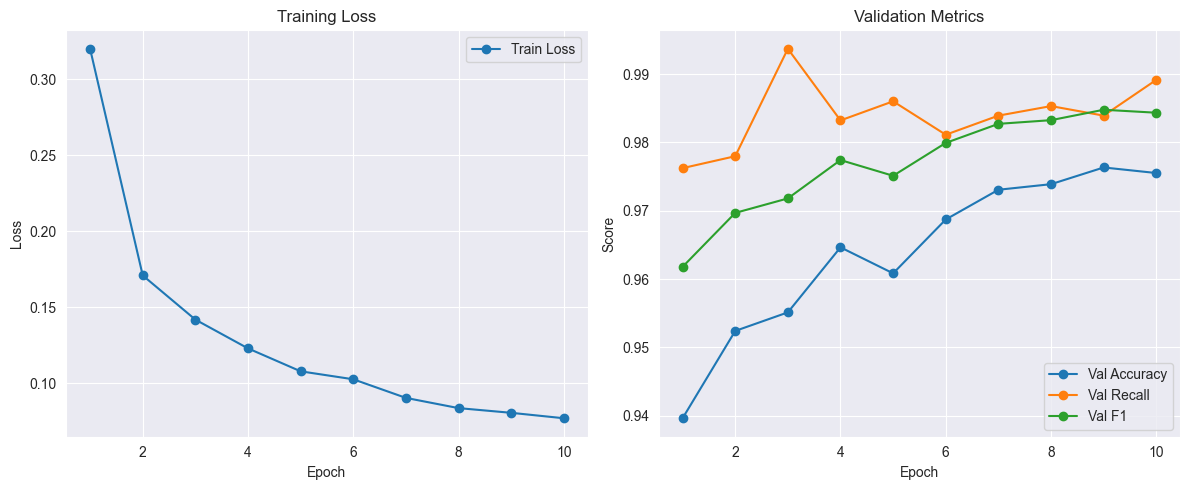

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

# Validation metrics
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, label='Val Accuracy', marker='o')
plt.plot(epochs, val_recalls, label='Val Recall', marker='o')
plt.plot(epochs, val_f1s, label='Val F1', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import classification_report

all_preds = []
all_targets = []
all_scores = []
all_labels = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        scores = torch.sigmoid(logits)
        
        if num_classes > 1:
            # Multi-class/One-hot: use argmax to get class index (0, 1, etc.)
            preds = torch.argmax(logits, dim=1)
            if yb.ndim > 1:
                targets = torch.argmax(yb, dim=1)
            else:
                targets = yb
        else:
            preds = (logits.squeeze() > 0).long()
            targets = yb.squeeze().long()
            
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_scores.append(scores.cpu())
        all_labels.append(yb.cpu())

Classification Report:
              precision    recall  f1-score   support

        Fail     0.9606    0.9276    0.9438       815
     Success     0.9796    0.9892    0.9844      2862

    accuracy                         0.9755      3677
   macro avg     0.9701    0.9584    0.9641      3677
weighted avg     0.9754    0.9755    0.9754      3677



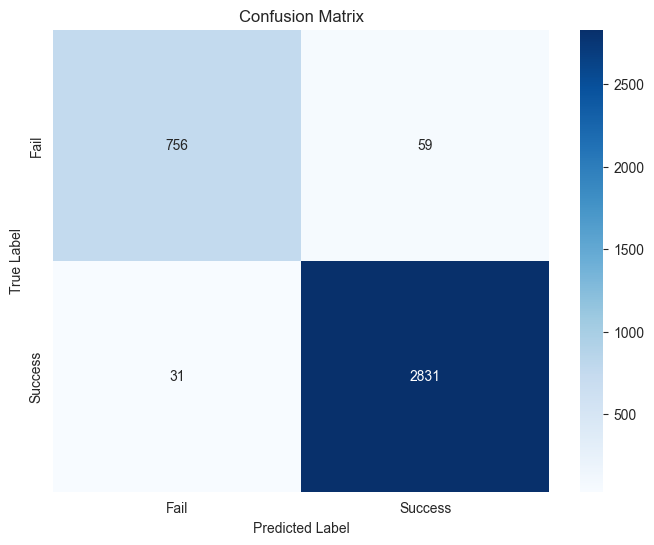

In [30]:
# Get readable class names from the label encoder
class_names = [str(c) for c in label_encoder.categories_[0]]
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# --- Visual Evaluation: Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [31]:
from sklearn.metrics import average_precision_score

In [32]:
y_score = torch.cat(all_scores).numpy().ravel()
y_true  = torch.cat(all_labels).numpy().ravel()

pr_auc = average_precision_score(y_true, y_score)

print("PR-AUC:", pr_auc)

PR-AUC: 0.990052962882864


In [33]:
torch.save(model.state_dict(), "../../saved_models/tcn_tiny_lm_embedding.pth")